In [1]:
import os
import xml.etree.ElementTree as ET
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml
import shutil
from collections import defaultdict
import random
from ultralytics import YOLO
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
import logging
import warnings
warnings.filterwarnings('ignore')

Could not save font_manager cache Lock error: Matplotlib failed to acquire the following lock file:
    C:\Users\ASUS\.matplotlib\fontlist-v390.json.matplotlib-lock
This maybe due to another process holding this lock file.  If you are sure no
other Matplotlib process is running, remove this file and try again.


In [2]:
# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print(f"🔥 CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")

✅ All libraries imported successfully!
🔥 CUDA Available: True
🎮 GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [ ]:
"""
Update these paths according to your dataset structure
"""
CONFIG = {
    
    'xml_folders': [
        'F:/Other project/SLIIT - codefest Dataset/try - Copy/Damage Detection Dataset for Concrete Structures with Multi-Feature Backgrounds/annotation', 
        'F:/Other project/SLIIT - codefest Dataset/try - Copy/trash/annotation'  
    ],
    'img_folders': [
        'F:/Other project/SLIIT - codefest Dataset/try - Copy/Damage Detection Dataset for Concrete Structures with Multi-Feature Backgrounds/img',   
        'F:/Other project/SLIIT - codefest Dataset/try - Copy/trash/img'       
    ],
    'output_dir': 'yolo_dataset',
    'model_size': 'n',  # Options: n, s, m, l, x (nano to extra-large)
    'epochs': 100,
    'batch_size': 16,
    'img_size': 640,
    'patience': 20,
    'confidence_threshold': 0.25,
    'k_folds': 5
}

print("📝 Configuration loaded:")
for key, value in CONFIG.items():
    print(f"   {key}: {value}")

📝 Configuration loaded:
   xml_folders: ['F:/Other project/SLIIT - codefest Dataset/try - Copy/Damage Detection Dataset for Concrete Structures with Multi-Feature Backgrounds/annotation', 'F:/Other project/SLIIT - codefest Dataset/try - Copy/trash/annotation']
   img_folders: ['F:/Other project/SLIIT - codefest Dataset/try - Copy/Damage Detection Dataset for Concrete Structures with Multi-Feature Backgrounds/img', 'F:/Other project/SLIIT - codefest Dataset/try - Copy/trash/img']
   output_dir: yolo_dataset
   model_size: n
   epochs: 100
   batch_size: 16
   img_size: 640
   patience: 20
   confidence_threshold: 0.25
   k_folds: 5


In [ ]:
class DatasetProcessor:
    """
    Process XML annotations and images for YOLO format
    """
    def __init__(self, base_path):
        self.base_path = Path(base_path)
        self.class_mapping = {
            'crack': 0,
            'Domestic Trash\tGarbage': 1,  # Handle the tab in trash annotation
            'trash': 1,
            'garbage': 1,
            'Domestic Trash': 1,
            'Garbage': 1
        }
        self.reverse_class_mapping = {0: 'damage', 1: 'trash'}
        
    def parse_xml_annotation(self, xml_path):
        """Parse XML annotation file and extract bounding boxes"""
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        annotations = []
        
        # Get image dimensions
        size = root.find('size')
        img_width = int(size.find('width').text)
        img_height = int(size.find('height').text)
        
        # Get image filename
        filename = root.find('filename').text
        
        # Extract all objects
        for obj in root.findall('object'):
            name = obj.find('name').text.strip()
            
            # Map class names to indices
            class_id = None
            for key, value in self.class_mapping.items():
                if key.lower() in name.lower():
                    class_id = value
                    break
            
            if class_id is None:
                logger.warning(f"Unknown class: {name}")
                continue
            
            bbox = obj.find('bndbox')
            xmin = int(bbox.find('xmin').text)
            ymin = int(bbox.find('ymin').text)
            xmax = int(bbox.find('xmax').text)
            ymax = int(bbox.find('ymax').text)
            
            # Convert to YOLO format (normalized center coordinates and dimensions)
            x_center = (xmin + xmax) / 2 / img_width
            y_center = (ymin + ymax) / 2 / img_height
            width = (xmax - xmin) / img_width
            height = (ymax - ymin) / img_height
            
            annotations.append({
                'filename': filename,
                'class_id': class_id,
                'x_center': x_center,
                'y_center': y_center,
                'width': width,
                'height': height,
                'img_width': img_width,
                'img_height': img_height,
                'class_name': self.reverse_class_mapping[class_id]
            })
        
        return annotations
    
    def process_dataset(self, xml_folder, img_folder=None):
        """Process all XML annotations and return dataset information"""
        xml_files = list(Path(xml_folder).glob('*.xml'))
        all_annotations = []
        
        print(f"🔍 Processing {len(xml_files)} XML files from {xml_folder}...")
        
        for xml_file in xml_files:
            try:
                annotations = self.parse_xml_annotation(xml_file)
                all_annotations.extend(annotations)
            except Exception as e:
                logger.error(f"❌ Error processing {xml_file}: {str(e)}")
        
        print(f"✅ Total annotations processed: {len(all_annotations)}")
        
        # Group by filename
        grouped_annotations = defaultdict(list)
        for ann in all_annotations:
            grouped_annotations[ann['filename']].append(ann)
        
        return grouped_annotations, all_annotations
    
    def create_yolo_dataset(self, annotations_dict, img_folders, output_dir):
        """Create YOLO format dataset"""
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        
        # Create directory structure
        for split in ['train', 'val', 'test']:
            (output_dir / split / 'images').mkdir(parents=True, exist_ok=True)
            (output_dir / split / 'labels').mkdir(parents=True, exist_ok=True)
        
        # Collect all image files
        all_images = []
        for img_folder in img_folders:
            img_path = Path(img_folder)
            if img_path.exists():
                print(f"📁 Scanning images in {img_path}")
                for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG', '*.JPEG']:
                    found_images = list(img_path.glob(ext))
                    all_images.extend(found_images)
                    if found_images:
                        print(f"   Found {len(found_images)} {ext} files")
        
        # Filter images that have annotations
        valid_images = []
        valid_annotations = []
        
        for img_path in all_images:
            img_name = img_path.name
            # Also try without extension for matching
            img_stem = img_path.stem
            
            if img_name in annotations_dict:
                valid_images.append(img_path)
                valid_annotations.append(annotations_dict[img_name])
            elif any(img_stem in ann_key for ann_key in annotations_dict.keys()):
                # Find matching annotation by stem
                for ann_key in annotations_dict.keys():
                    if img_stem in ann_key or ann_key.split('.')[0] == img_stem:
                        valid_images.append(img_path)
                        valid_annotations.append(annotations_dict[ann_key])
                        break
        
        print(f"✅ Found {len(valid_images)} images with annotations")
        
        if len(valid_images) == 0:
            raise ValueError("❌ No images found with matching annotations!")
        
        # Split dataset using stratified approach based on dominant class
        stratify_labels = []
        for annotations in valid_annotations:
            # Use the most frequent class in the image for stratification
            classes = [ann['class_id'] for ann in annotations]
            dominant_class = max(set(classes), key=classes.count)
            stratify_labels.append(dominant_class)
        
        # Create train/val/test splits (70/20/10)
        X_temp, X_test, _, y_test_idx = train_test_split(
            list(zip(valid_images, valid_annotations)), 
            range(len(valid_images)),
            test_size=0.1, 
            random_state=42, 
            stratify=stratify_labels
        )
        
        # Get remaining stratify labels
        remaining_labels = [stratify_labels[i] for i in range(len(stratify_labels)) if i not in y_test_idx]
        
        X_train, X_val, _, _ = train_test_split(
            X_temp, 
            range(len(X_temp)),
            test_size=0.22,  # 0.22 of 0.9 = ~0.2 of total
            random_state=42, 
            stratify=remaining_labels
        )
        
        splits = {
            'train': X_train,
            'val': X_val,
            'test': X_test
        }
        
        split_stats = {}
        
        # Copy images and create label files
        for split_name, split_data in splits.items():
            print(f"📊 Processing {split_name} split with {len(split_data)} images")
            
            class_counts = defaultdict(int)
            total_objects = 0
            
            for img_path, annotations in split_data:
                # Copy image
                dst_img_path = output_dir / split_name / 'images' / img_path.name
                shutil.copy2(img_path, dst_img_path)
                
                # Create label file
                label_path = output_dir / split_name / 'labels' / f"{img_path.stem}.txt"
                with open(label_path, 'w') as f:
                    for ann in annotations:
                        f.write(f"{ann['class_id']} {ann['x_center']:.6f} {ann['y_center']:.6f} "
                               f"{ann['width']:.6f} {ann['height']:.6f}\n")
                        class_counts[ann['class_name']] += 1
                        total_objects += 1
            
            split_stats[split_name] = {
                'images': len(split_data),
                'objects': total_objects,
                'classes': dict(class_counts)
            }
        
        # Create dataset yaml file
        yaml_content = {
            'train': str('F:\Other project\SLIIT - codefest Dataset\script 1\yolo_dataset' / 'train' / 'images'),
            'val': str('F:\Other project\SLIIT - codefest Dataset\script 1\yolo_dataset' / 'val' / 'images'),
            'test': str('F:\Other project\SLIIT - codefest Dataset\script 1\yolo_dataset' / 'test' / 'images'),
            'nc': 2,
            'names': ['damage', 'trash']
        }
        
        with open(output_dir / 'dataset.yaml', 'w') as f:
            yaml.dump(yaml_content, f)
        
        return str(output_dir / 'dataset.yaml'), split_stats

print("✅ DatasetProcessor class loaded!")

✅ DatasetProcessor class loaded!


In [6]:
"""
This cell processes your XML annotations and creates YOLO format dataset
"""
print("🚀 Starting dataset processing...")

# Initialize processor
processor = DatasetProcessor(CONFIG['output_dir'])

# Process all XML files from both folders
all_annotations = {}
all_raw_annotations = []

for xml_folder in CONFIG['xml_folders']:
    if os.path.exists(xml_folder):
        annotations_dict, raw_annotations = processor.process_dataset(xml_folder)
        all_annotations.update(annotations_dict)
        all_raw_annotations.extend(raw_annotations)
        print(f"✅ Processed {xml_folder}")
    else:
        print(f"⚠️  Warning: {xml_folder} does not exist!")

print(f"\n📊 Dataset Summary:")
print(f"   Total annotated images: {len(all_annotations)}")
print(f"   Total object instances: {len(all_raw_annotations)}")

# Analyze class distribution
class_counts = defaultdict(int)
for ann in all_raw_annotations:
    class_counts[ann['class_name']] += 1

print(f"   Class distribution:")
for class_name, count in class_counts.items():
    print(f"     {class_name}: {count} instances")

# Create YOLO dataset
if all_annotations:
    dataset_yaml, split_stats = processor.create_yolo_dataset(
        all_annotations, 
        CONFIG['img_folders'], 
        CONFIG['output_dir']
    )
    
    print(f"\n✅ YOLO dataset created successfully!")
    print(f"📁 Dataset YAML: {dataset_yaml}")
    
    # Display split statistics
    print(f"\n📊 Dataset Split Statistics:")
    for split, stats in split_stats.items():
        print(f"   {split.upper()}:")
        print(f"     Images: {stats['images']}")
        print(f"     Objects: {stats['objects']}")
        print(f"     Classes: {stats['classes']}")
else:
    print("❌ No annotations found! Please check your paths.")

🚀 Starting dataset processing...
🔍 Processing 250 XML files from F:/Other project/SLIIT - codefest Dataset/try - Copy/Damage Detection Dataset for Concrete Structures with Multi-Feature Backgrounds/annotation...


ERROR:__main__:❌ Error processing F:\Other project\SLIIT - codefest Dataset\try - Copy\Damage Detection Dataset for Concrete Structures with Multi-Feature Backgrounds\annotation\378810.xml: float division by zero


✅ Total annotations processed: 840
✅ Processed F:/Other project/SLIIT - codefest Dataset/try - Copy/Damage Detection Dataset for Concrete Structures with Multi-Feature Backgrounds/annotation
🔍 Processing 248 XML files from F:/Other project/SLIIT - codefest Dataset/try - Copy/trash/annotation...


✅ Total annotations processed: 241
✅ Processed F:/Other project/SLIIT - codefest Dataset/try - Copy/trash/annotation

📊 Dataset Summary:
   Total annotated images: 465
   Total object instances: 1081
   Class distribution:
     damage: 840 instances
     trash: 241 instances
📁 Scanning images in F:\Other project\SLIIT - codefest Dataset\try - Copy\Damage Detection Dataset for Concrete Structures with Multi-Feature Backgrounds\img
   Found 250 *.png files
   Found 250 *.PNG files
📁 Scanning images in F:\Other project\SLIIT - codefest Dataset\try - Copy\trash\img
   Found 250 *.jpg files
   Found 250 *.JPG files
✅ Found 930 images with annotations
📊 Processing train split with 652 images
📊 Processing val split with 185 images
📊 Processing test split with 93 images

✅ YOLO dataset created successfully!
📁 Dataset YAML: yolo_dataset\dataset.yaml

📊 Dataset Split Statistics:
   TRAIN:
     Images: 652
     Objects: 1498
     Classes: {'trash': 340, 'damage': 1158}
   VAL:
     Images: 185
  

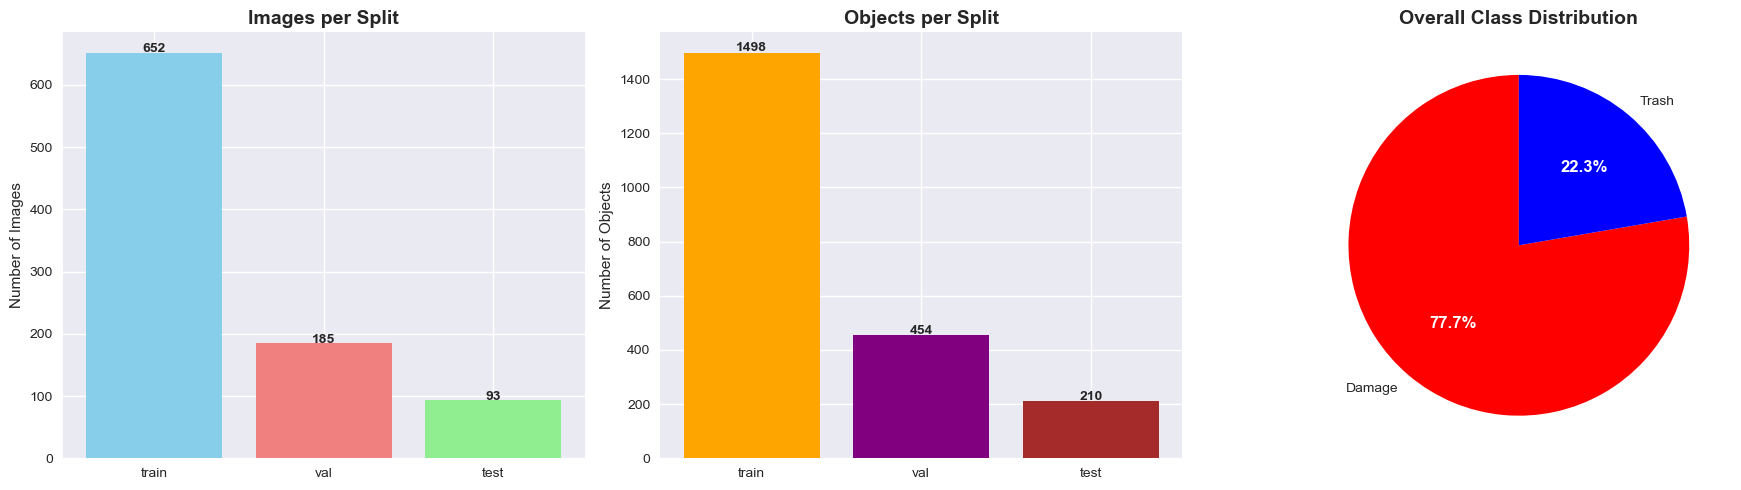

📈 Dataset statistics saved as 'dataset_statistics.png'


In [7]:

"""
Create visualizations of your dataset
"""
if 'split_stats' in locals():
    # Plot 1: Dataset split distribution
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Images per split
    splits = list(split_stats.keys())
    image_counts = [split_stats[split]['images'] for split in splits]
    object_counts = [split_stats[split]['objects'] for split in splits]
    
    axes[0].bar(splits, image_counts, color=['skyblue', 'lightcoral', 'lightgreen'])
    axes[0].set_title('Images per Split', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Number of Images')
    for i, count in enumerate(image_counts):
        axes[0].text(i, count + 1, str(count), ha='center', fontweight='bold')
    
    # Objects per split
    axes[1].bar(splits, object_counts, color=['orange', 'purple', 'brown'])
    axes[1].set_title('Objects per Split', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Number of Objects')
    for i, count in enumerate(object_counts):
        axes[1].text(i, count + 5, str(count), ha='center', fontweight='bold')
    
    # Overall class distribution
    total_damage = sum(stats['classes'].get('damage', 0) for stats in split_stats.values())
    total_trash = sum(stats['classes'].get('trash', 0) for stats in split_stats.values())
    
    classes = ['Damage', 'Trash']
    class_totals = [total_damage, total_trash]
    colors = ['red', 'blue']
    
    wedges, texts, autotexts = axes[2].pie(class_totals, labels=classes, autopct='%1.1f%%', 
                                          colors=colors, startangle=90)
    axes[2].set_title('Overall Class Distribution', fontsize=14, fontweight='bold')
    
    # Make percentage text bold
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(12)
    
    plt.tight_layout()
    plt.savefig('dataset_statistics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"📈 Dataset statistics saved as 'dataset_statistics.png'")

In [8]:
class MultiClassDetector:
    """
    Multi-class object detection using YOLOv8
    """
    def __init__(self, dataset_yaml, model_size='n'):
        self.dataset_yaml = dataset_yaml
        self.model_size = model_size
        self.model = None
        self.training_results = None
        self.best_model_path = None
        
    def initialize_model(self):
        """Initialize YOLOv8 model"""
        model_name = f'yolov8{self.model_size}.pt'
        self.model = YOLO(model_name)
        print(f"✅ Initialized {model_name} model")
        
    def train_model(self, epochs=100, patience=20, batch_size=16, img_size=640):
        """Train the YOLO model"""
        if self.model is None:
            self.initialize_model()
        
        print(f"🏋️ Starting training with {epochs} epochs...")
        print(f"   Batch size: {batch_size}")
        print(f"   Image size: {img_size}")
        print(f"   Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")
        
        # Configure training parameters
        train_args = {
            'data': self.dataset_yaml,
            'epochs': epochs,
            'patience': patience,
            'batch': batch_size,
            'imgsz': img_size,
            'device': 'cuda' if torch.cuda.is_available() else 'cpu',
            'workers': 4,
            'project': 'runs/detect',
            'name': 'multiclass_detector',
            'save_period': 10,
            'cache': True,
            'augment': True,
            'mosaic': 1.0,
            'mixup': 0.1,
            'copy_paste': 0.3,
            'degrees': 10.0,
            'translate': 0.2,
            'scale': 0.5,
            'shear': 2.0,
            'perspective': 0.0,
            'flipud': 0.5,
            'fliplr': 0.5,
            'hsv_h': 0.015,
            'hsv_s': 0.7,
            'hsv_v': 0.4,
        }
        
        # Train the model
        self.training_results = self.model.train(**train_args)
        
        # Store best model path
        self.best_model_path = f"runs/detect/multiclass_detector/weights/best.pt"
        
        print(f"✅ Training completed!")
        print(f"🏆 Best model saved at: {self.best_model_path}")
        
        return self.training_results
    
    def load_best_model(self):
        """Load the best trained model"""
        if self.best_model_path and os.path.exists(self.best_model_path):
            self.model = YOLO(self.best_model_path)
            print(f"✅ Loaded best model from {self.best_model_path}")
        else:
            print("❌ Best model not found!")
    
    def evaluate_model(self):
        """Evaluate the trained model"""
        if self.model is None:
            raise ValueError("❌ Model not trained yet!")
        
        print("📊 Evaluating model...")
        results = self.model.val(data=self.dataset_yaml, split='val')
        
        print(f"📈 Validation Results:")
        print(f"   mAP@0.5: {results.box.map50:.4f}")
        print(f"   mAP@0.5-0.95: {results.box.map:.4f}")
        print(f"   Precision: {results.box.p.mean():.4f}")
        print(f"   Recall: {results.box.r.mean():.4f}")
        
        return results
    
    def predict(self, image_path, confidence_threshold=0.25, save_results=True):
        """Make predictions on new images"""
        if self.model is None:
            raise ValueError("❌ Model not trained yet!")
        
        results = self.model(image_path, conf=confidence_threshold, save=save_results)
        return results
    
    def export_model(self, format='onnx'):
        """Export model for edge deployment"""
        if self.model is None:
            raise ValueError("❌ Model not trained yet!")
        
        print(f"📦 Exporting model to {format} format for edge deployment...")
        exported_model = self.model.export(format=format, optimize=True)
        print(f"✅ Model exported to: {exported_model}")
        
        return exported_model

print("✅ MultiClassDetector class loaded!")



✅ MultiClassDetector class loaded!


In [10]:
"""
Initialize the detector and start training
"""
if 'dataset_yaml' in locals():
    # Initialize detector
    detector = MultiClassDetector(dataset_yaml, CONFIG['model_size'])
    
    print("🚀 Starting model training...")
    print("⏰ This may take a while depending on your dataset size and hardware...")
    
    # Train the model
    training_results = detector.train_model(
        epochs=CONFIG['epochs'],
        patience=CONFIG['patience'],
        batch_size=CONFIG['batch_size'],
        img_size=CONFIG['img_size']
    )
    
    print("🎉 Training completed!")
else:
    print("❌ Dataset YAML not found. Please run the dataset processing cells first.")


🚀 Starting model training...
⏰ This may take a while depending on your dataset size and hardware...
✅ Initialized yolov8n.pt model
🏋️ Starting training with 100 epochs...
   Batch size: 16
   Image size: 640
   Device: CUDA
Ultralytics 8.3.176  Python-3.11.13 torch-2.0.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset\dataset.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixu

AMP: checks passed 
train: Fast image access  (ping: 0.10.0 ms, read: 203.1238.1 MB/s, size: 1968.6 KB)


train: Scanning F:\Other project\SLIIT - codefest Dataset\script 1\yolo_dataset\train\labels... 422 images, 0 backgrounds, 0 corrupt: 100%|██████████| 422/422 [00:01<00:00, 268.12it/s]

train: F:\Other project\SLIIT - codefest Dataset\script 1\yolo_dataset\train\images\Datacluster Trash (236).jpg: corrupt JPEG restored and saved
train: F:\Other project\SLIIT - codefest Dataset\script 1\yolo_dataset\train\images\Datacluster Trash (237).jpg: corrupt JPEG restored and saved
train: F:\Other project\SLIIT - codefest Dataset\script 1\yolo_dataset\train\images\Datacluster Trash (239).jpg: corrupt JPEG restored and saved
train: F:\Other project\SLIIT - codefest Dataset\script 1\yolo_dataset\train\images\Datacluster Trash (240).jpg: corrupt JPEG restored and saved
train: New cache created: F:\Other project\SLIIT - codefest Dataset\script 1\yolo_dataset\train\labels.cache


WARNING cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.


...

    100/100       2.1G      1.449       1.62      1.601         16        640: 100%|██████████| 27/27 [00:04<00:00,  5.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:01<00:00,  5.51it/s]

                   all        170        408      0.578      0.641      0.616      0.371



100 epochs completed in 0.178 hours.
Optimizer stripped from runs\detect\multiclass_detector2\weights\last.pt, 6.2MB
Optimizer stripped from runs\detect\multiclass_detector2\weights\best.pt, 6.2MB

Validating runs\detect\multiclass_detector2\weights\best.pt...
Ultralytics 8.3.176  Python-3.11.13 torch-2.0.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:02<00:00,  2.10it/s]


                   all        170        408      0.579      0.657      0.646      0.415
                damage         83        319      0.474      0.414      0.402      0.176
                 trash         87         89      0.684      0.901      0.889      0.655
Speed: 0.7ms preprocess, 10.4ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to runs\detect\multiclass_detector2
✅ Training completed!
🏆 Best model saved at: runs/detect/multiclass_detector/weights/best.pt
🎉 Training completed!


In [11]:

# Cell 9: Model Evaluation and Visualization
class ModelEvaluator:
    """
    Evaluate and visualize model performance
    """
    def __init__(self, model, dataset_yaml):
        self.model = model
        self.dataset_yaml = dataset_yaml
        
    def plot_training_curves(self, results_dir):
        """Plot training curves"""
        results_path = Path(results_dir)
        csv_path = results_path / 'results.csv'
        
        if not csv_path.exists():
            print(f"❌ Results file not found at {csv_path}")
            return
        
        # Read training results
        df = pd.read_csv(csv_path)
        df = df.fillna(0)  # Fill NaN values
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # Loss curves
        if 'train/box_loss' in df.columns:
            axes[0,0].plot(df['epoch'], df['train/box_loss'], label='Box Loss', color='blue', linewidth=2)
        if 'train/cls_loss' in df.columns:
            axes[0,0].plot(df['epoch'], df['train/cls_loss'], label='Class Loss', color='red', linewidth=2)
        if 'train/dfl_loss' in df.columns:
            axes[0,0].plot(df['epoch'], df['train/dfl_loss'], label='DFL Loss', color='green', linewidth=2)
        
        axes[0,0].set_title('Training Losses', fontsize=14, fontweight='bold')
        axes[0,0].set_xlabel('Epoch')
        axes[0,0].set_ylabel('Loss')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
        
        # Validation losses
        if 'val/box_loss' in df.columns:
            axes[0,1].plot(df['epoch'], df['val/box_loss'], label='Box Loss', color='blue', linewidth=2)
        if 'val/cls_loss' in df.columns:
            axes[0,1].plot(df['epoch'], df['val/cls_loss'], label='Class Loss', color='red', linewidth=2)
        if 'val/dfl_loss' in df.columns:
            axes[0,1].plot(df['epoch'], df['val/dfl_loss'], label='DFL Loss', color='green', linewidth=2)
        
        axes[0,1].set_title('Validation Losses', fontsize=14, fontweight='bold')
        axes[0,1].set_xlabel('Epoch')
        axes[0,1].set_ylabel('Loss')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)
        
        # mAP curves
        if 'metrics/mAP50(B)' in df.columns:
            axes[1,0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.5', color='purple', linewidth=2)
        if 'metrics/mAP50-95(B)' in df.columns:
            axes[1,0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5-0.95', color='orange', linewidth=2)
        
        axes[1,0].set_title('Mean Average Precision', fontsize=14, fontweight='bold')
        axes[1,0].set_xlabel('Epoch')
        axes[1,0].set_ylabel('mAP')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
        
        # Precision/Recall
        if 'metrics/precision(B)' in df.columns:
            axes[1,1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='green', linewidth=2)
        if 'metrics/recall(B)' in df.columns:
            axes[1,1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='red', linewidth=2)
        
        axes[1,1].set_title('Precision and Recall', fontsize=14, fontweight='bold')
        axes[1,1].set_xlabel('Epoch')
        axes[1,1].set_ylabel('Score')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("📈 Training curves saved as 'training_curves.png'")
    
    def visualize_predictions(self, test_images, num_samples=6):
        """Visualize model predictions on test images"""
        if isinstance(test_images, str):
            test_images = list(Path(test_images).glob('*.jpg')) + list(Path(test_images).glob('*.png'))
        
        sample_images = random.sample(test_images, min(num_samples, len(test_images)))
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()
        
        for idx, img_path in enumerate(sample_images):
            # Make prediction
            results = self.model(str(img_path), conf=0.25)
            
            # Load and display image
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            axes[idx].imshow(img)
            axes[idx].set_title(f'Image: {img_path.name}', fontsize=12, fontweight='bold')
            axes[idx].axis('off')
            
            # Draw bounding boxes
            if len(results[0].boxes) > 0:
                boxes = results[0].boxes
                for box in boxes:
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    conf = box.conf[0].cpu().numpy()
                    cls = int(box.cls[0].cpu().numpy())
                    
                    # Draw rectangle
                    color = 'red' if cls == 0 else 'blue'  # damage: red, trash: blue
                    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                                       fill=False, color=color, linewidth=2)
                    axes[idx].add_patch(rect)
                    
                    # Add label
                    label = f"{'Damage' if cls == 0 else 'Trash'}: {conf:.2f}"
                    axes[idx].text(x1, y1-10, label, color=color, fontweight='bold',
                                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
        
        plt.tight_layout()
        plt.savefig('prediction_samples.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("🔍 Prediction samples saved as 'prediction_samples.png'")

print("✅ ModelEvaluator class loaded!")

✅ ModelEvaluator class loaded!


📊 Evaluating model performance...
📊 Evaluating model...
Ultralytics 8.3.176  Python-3.11.13 torch-2.0.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 65.2136.8 MB/s, size: 882.0 KB)


val: Scanning F:\Other project\SLIIT - codefest Dataset\script 1\yolo_dataset\val\labels.cache... 170 images, 0 backgrounds, 0 corrupt: 100%|██████████| 170/170 [00:00<?, ?it/s]

val: F:\Other project\SLIIT - codefest Dataset\script 1\yolo_dataset\val\images\Datacluster Trash (240).jpg: corrupt JPEG restored and saved


WARNING cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.


val: Caching images (0.2GB RAM): 100%|██████████| 170/170 [00:01<00:00, 105.14it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 11/11 [00:03<00:00,  3.29it/s]


                   all        170        408      0.573      0.658      0.643      0.415
                damage         83        319      0.461      0.414      0.396      0.174
                 trash         87         89      0.685      0.902       0.89      0.657
Speed: 1.3ms preprocess, 12.9ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to runs\detect\multiclass_detector22
📈 Validation Results:
   mAP@0.5: 0.6428
   mAP@0.5-0.95: 0.4155
   Precision: 0.5728
   Recall: 0.6581
❌ Results file not found at runs\detect\multiclass_detector\results.csv
🔍 Visualizing predictions on test images...

image 1/1 f:\Other project\SLIIT - codefest Dataset\script 1\yolo_dataset\test\images\Datacluster Trash (197).jpg: 480x640 1 trash, 309.9ms
Speed: 3.3ms preprocess, 309.9ms inference, 7.0ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 f:\Other project\SLIIT - codefest Dataset\script 1\yolo_dataset\test\images\Datacluster Trash (109).jpg: 640x480 3 trashs, 262.8m

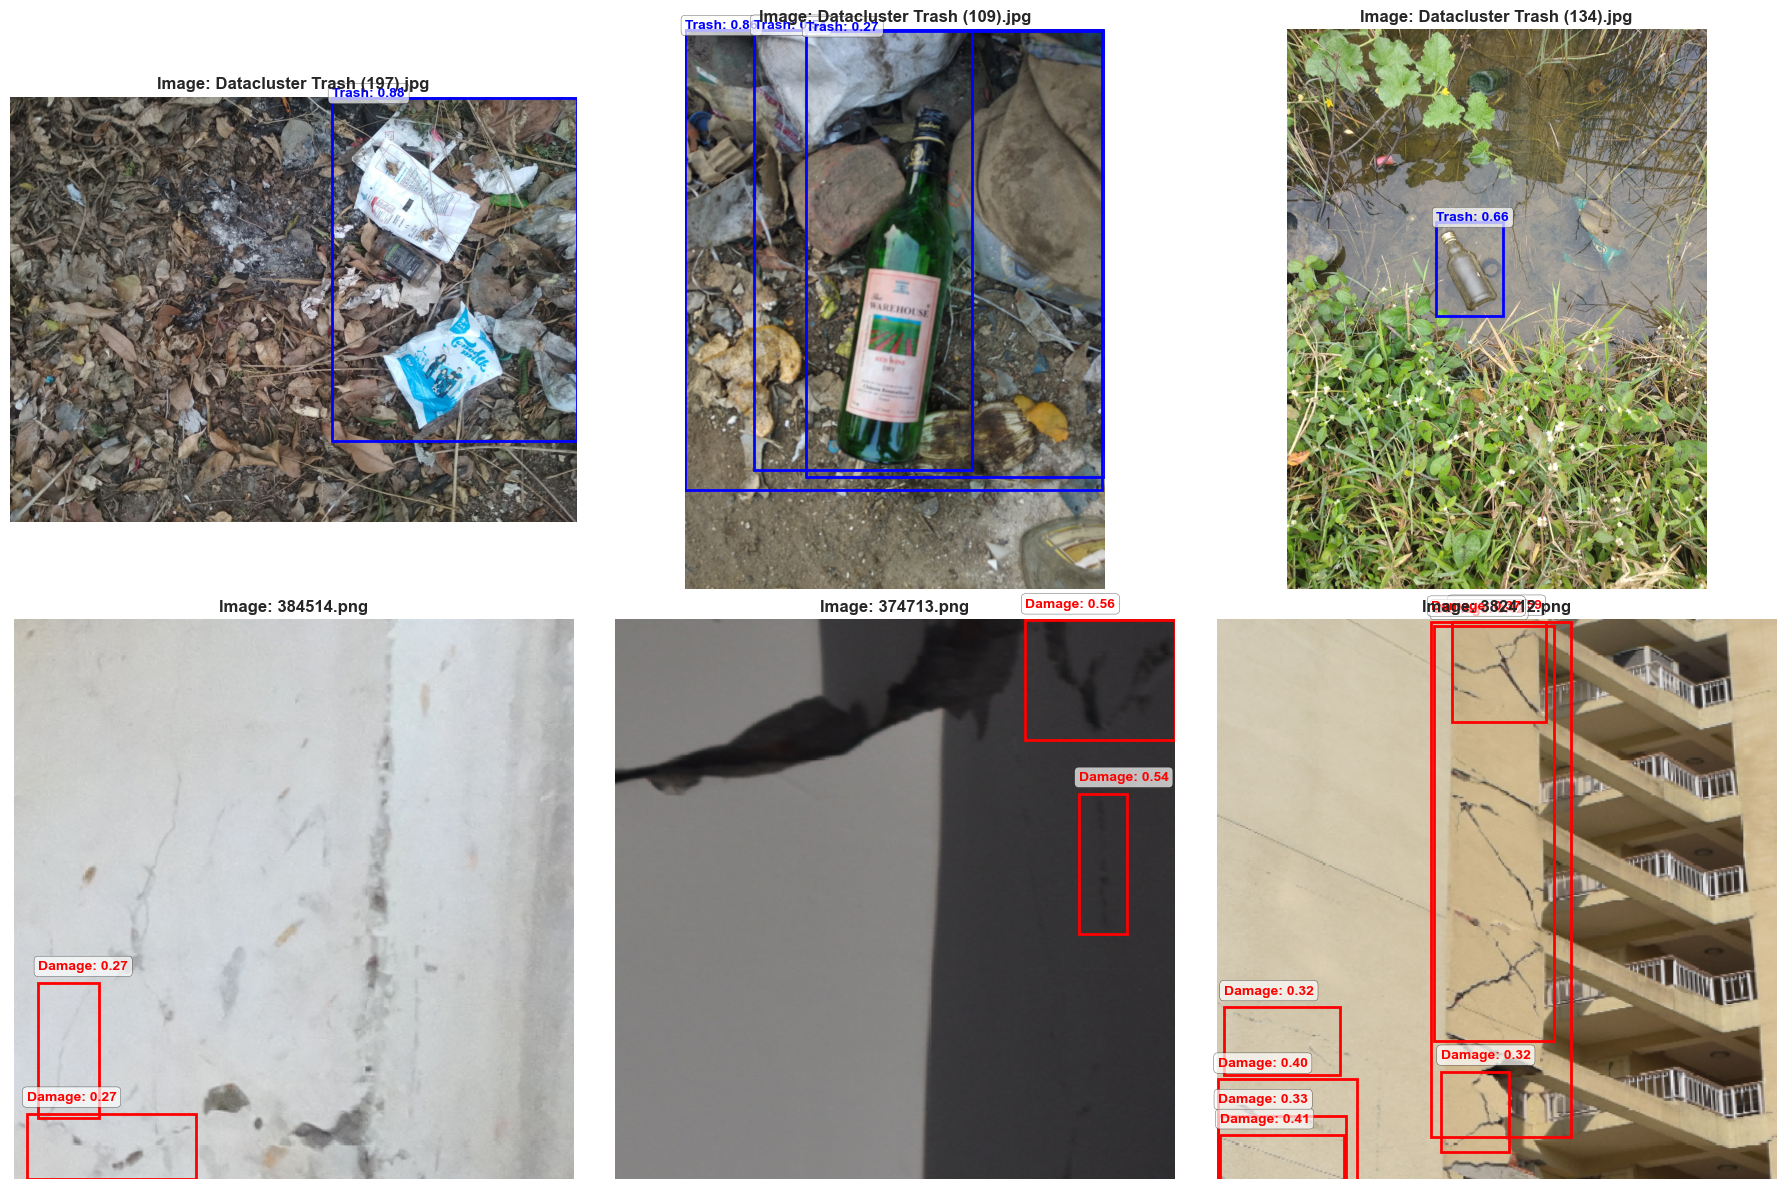

🔍 Prediction samples saved as 'prediction_samples.png'


In [12]:
"""
Evaluate the trained model and create visualizations
"""
if 'detector' in locals() and detector.model is not None:
    # Initialize evaluator
    evaluator = ModelEvaluator(detector.model, dataset_yaml)
    
    # Evaluate model performance
    print("📊 Evaluating model performance...")
    val_results = detector.evaluate_model()
    
    # Plot training curves
    results_dir = 'runs/detect/multiclass_detector'
    if os.path.exists(results_dir):
        evaluator.plot_training_curves(results_dir)
    
    # Visualize predictions on test images
    test_images_path = Path(CONFIG['output_dir']) / 'test' / 'images'
    if test_images_path.exists():
        print("🔍 Visualizing predictions on test images...")
        test_images = list(test_images_path.glob('*.jpg')) + list(test_images_path.glob('*.png'))
        if test_images:
            evaluator.visualize_predictions(test_images, num_samples=6)
        else:
            print("❌ No test images found")
    
else:
    print("❌ Model not trained yet. Please run the training cell first.")


🔄 Starting 5-fold cross validation...
⚠️  This will take significant time. Consider reducing epochs for faster execution.

🔄 Training fold 1/5
Ultralytics 8.3.176  Python-3.11.13 torch-2.0.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False

train: Scanning F:\Other project\SLIIT - codefest Dataset\script 1\yolo_dataset\train\labels.cache... 422 images, 0 backgrounds, 0 corrupt: 100%|██████████| 422/422 [00:00<?, ?it/s]

train: F:\Other project\SLIIT - codefest Dataset\script 1\yolo_dataset\train\images\Datacluster Trash (236).jpg: corrupt JPEG restored and saved
train: F:\Other project\SLIIT - codefest Dataset\script 1\yolo_dataset\train\images\Datacluster Trash (237).jpg: corrupt JPEG restored and saved
train: F:\Other project\SLIIT - codefest Dataset\script 1\yolo_dataset\train\images\Datacluster Trash (239).jpg: corrupt JPEG restored and saved
train: F:\Other project\SLIIT - codefest Dataset\script 1\yolo_dataset\train\images\Datacluster Trash (240).jpg: corrupt JPEG restored and saved
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access  (ping: 0.10.0 ms, read: 534.7523.6 MB/s, size: 3358.4 KB)


val: Scanning F:\Other project\SLIIT - codefest Dataset\script 1\yolo_dataset\val\labels.cache... 170 images, 0 backgrounds, 0 corrupt: 100%|██████████| 170/170 [00:00<?, ?it/s]

...

                   all        170        408      0.346      0.384      0.336      0.219
Speed: 0.4ms preprocess, 6.9ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to runs\cv\fold_4
Ultralytics 8.3.176  Python-3.11.13 torch-2.0.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2171.4940.2 MB/s, size: 2487.3 KB)


val: Scanning F:\Other project\SLIIT - codefest Dataset\script 1\yolo_dataset\val\labels.cache... 170 images, 0 backgrounds, 0 corrupt: 100%|██████████| 170/170 [00:00<?, ?it/s]

val: F:\Other project\SLIIT - codefest Dataset\script 1\yolo_dataset\val\images\Datacluster Trash (240).jpg: corrupt JPEG restored and saved



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 170/170 [00:03<00:00, 54.34it/s]


                   all        170        408      0.342      0.384      0.337       0.22
Speed: 0.5ms preprocess, 11.8ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to runs\cv\fold_42
✅ Fold 5 completed:
   mAP@0.5: 0.3369
   mAP@0.5-0.95: 0.2196

📊 Cross-Validation Results Summary:
           fold     mAP50  mAP50-95  precision    recall
count  5.000000  5.000000  5.000000   5.000000  5.000000
mean   3.000000  0.348304  0.224540   0.342151  0.414481
std    1.581139  0.008637  0.010653   0.025504  0.030529
min    1.000000  0.336863  0.213131   0.321641  0.380314
25%    2.000000  0.343187  0.218191   0.323929  0.384224
50%    3.000000  0.348553  0.219594   0.338041  0.422745
75%    4.000000  0.354420  0.235105   0.342190  0.442499
max    5.000000  0.358495  0.236679   0.384955  0.442623


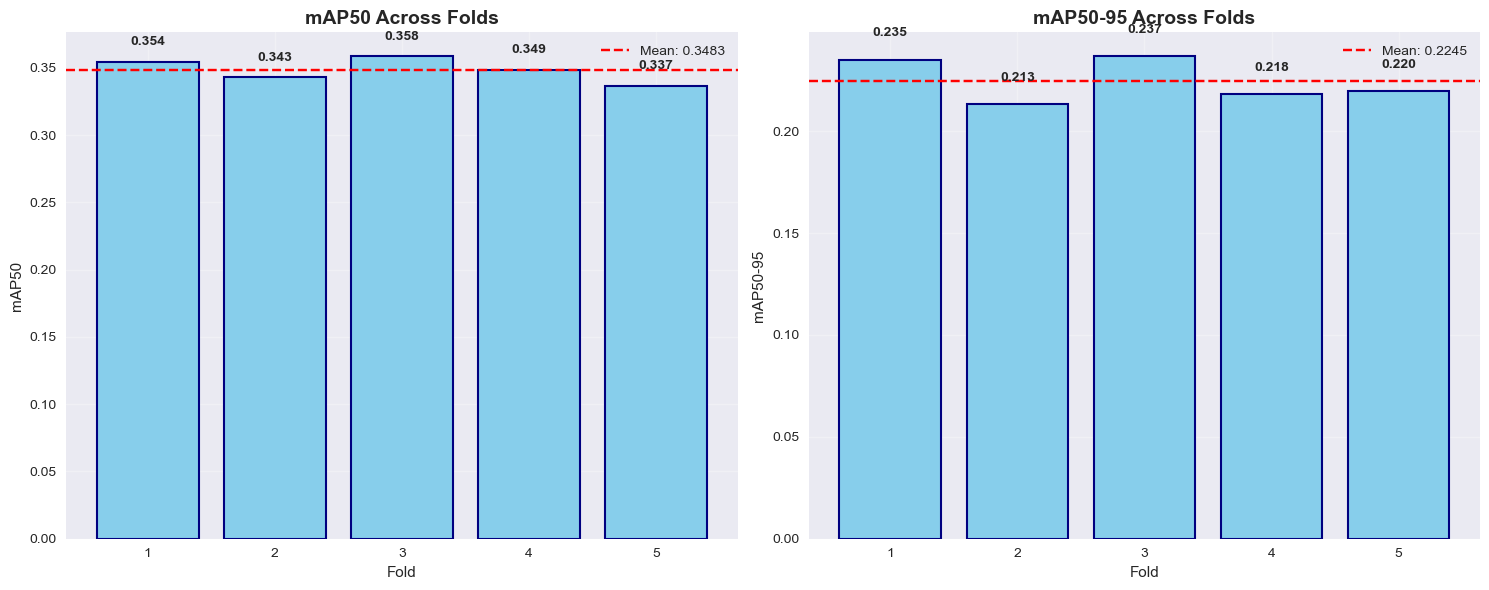

In [14]:
"""
Perform cross-validation for more robust evaluation
"""
def perform_cross_validation(dataset_yaml, k_folds=5, epochs=50):
    """Perform k-fold cross validation"""
    print(f"🔄 Starting {k_folds}-fold cross validation...")
    print("⚠️  This will take significant time. Consider reducing epochs for faster execution.")
    
    cv_results = []
    
    for fold in range(k_folds):
        print(f"\n🔄 Training fold {fold + 1}/{k_folds}")
        
        # Initialize new model for each fold
        temp_model = YOLO(f'yolov8{CONFIG["model_size"]}.pt')
        
        # Train with different random seed for each fold
        results = temp_model.train(
            data=dataset_yaml,
            epochs=50,
            patience=15,
            batch=1,  # minimal batch size
            imgsz=320,  # smaller image size if supported
            device='cuda' if torch.cuda.is_available() else 'cpu',
            # device='cpu',
            project='runs/cv',
            name=f'fold_{fold}',
            seed=fold * 42,
            verbose=False
        )
        
        # Validate
        val_results = temp_model.val()
        cv_results.append({
            'fold': fold + 1,
            'mAP50': float(val_results.box.map50),
            'mAP50-95': float(val_results.box.map),
            'precision': float(val_results.box.p.mean()),
            'recall': float(val_results.box.r.mean())
        })
        
        print(f"✅ Fold {fold + 1} completed:")
        print(f"   mAP@0.5: {cv_results[-1]['mAP50']:.4f}")
        print(f"   mAP@0.5-0.95: {cv_results[-1]['mAP50-95']:.4f}")
    
    # Calculate statistics across folds
    cv_df = pd.DataFrame(cv_results)
    cv_summary = cv_df.describe()
    
    print(f"\n📊 Cross-Validation Results Summary:")
    print(cv_summary)
    
    # Plot CV results
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    metrics = ['mAP50', 'mAP50-95']
    for i, metric in enumerate(metrics):
        axes[i].bar(range(1, k_folds + 1), cv_df[metric], 
                   color='skyblue', edgecolor='navy', linewidth=1.5)
        axes[i].axhline(cv_df[metric].mean(), color='red', linestyle='--', 
                       label=f'Mean: {cv_df[metric].mean():.4f}')
        axes[i].set_title(f'{metric} Across Folds', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Fold')
        axes[i].set_ylabel(metric)
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        
        # Add value labels on bars
        for j, v in enumerate(cv_df[metric]):
            axes[i].text(j + 1, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('cross_validation_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return cv_results, cv_summary

# Uncomment the following lines to run cross-validation
if 'dataset_yaml' in locals():
    cv_results, cv_summary = perform_cross_validation(dataset_yaml, CONFIG['k_folds'], epochs=50)
else:
    print("❌ Dataset YAML not found. Please run the dataset processing cells first.")

# print("⚠️  Cross-validation cell ready. Uncomment lines above to run (will take significant time).")


In [21]:
"""
Export the trained model for edge device deployment
"""
if 'detector' in locals() and detector.model is not None:
    print("📦 Exporting model for edge deployment...")
    
    # Export to ONNX (most compatible format for edge devices)
    try:
        onnx_model = detector.export_model('onnx')
        print(f"✅ ONNX model exported successfully!")
    except Exception as e:
        print(f"❌ ONNX export failed: {str(e)}")
    
    # Also try TensorFlow Lite for mobile devices
    try:
        print("📱 Exporting TensorFlow Lite model...")
        tflite_model = detector.export_model('tflite')
        print(f"✅ TensorFlow Lite model exported successfully!")
    except Exception as e:
        print(f"❌ TensorFlow Lite export failed: {str(e)}")
    
    # Export to TensorRT for NVIDIA devices (if available)
    if torch.cuda.is_available():
        try:
            print("🚀 Exporting TensorRT model...")
            tensorrt_model = detector.export_model('engine')
            print(f"✅ TensorRT model exported successfully!")
        except Exception as e:
            print(f"❌ TensorRT export failed: {str(e)}")
    
    print("\n📋 Model Export Summary:")
    print("   Use ONNX (.onnx) for general edge deployment")
    print("   Use TensorFlow Lite (.tflite) for mobile/Android deployment")
    print("   Use TensorRT (.engine) for NVIDIA GPU acceleration")
    
else:
    print("❌ Model not trained yet. Please run the training cell first.")


📦 Exporting model for edge deployment...
📦 Exporting model to onnx format for edge deployment...
Ultralytics 8.3.176  Python-3.11.13 torch-2.0.1+cu118 CPU (AMD Ryzen 7 6800H with Radeon Graphics)

PyTorch: starting from 'runs\detect\multiclass_detector2\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (6.0 MB)

ONNX: starting export with onnx 1.17.0 opset 17...
============= Diagnostic Run torch.onnx.export version 2.0.1+cu118 =============
verbose: False, log level: Level.ERROR
======================= 0 NONE 0 NOTE 0 WARNING 0 ERROR ========================

ONNX: slimming with onnxslim 0.1.64...
ONNX: export success  1.0s, saved as 'runs\detect\multiclass_detector2\weights\best.onnx' (11.7 MB)

Export complete (1.2s)
Results saved to F:\Other project\SLIIT - codefest Dataset\script 1\runs\detect\multiclass_detector2\weights
Predict:         yolo predict task=detect model=runs\detect\multiclass_detector2\weights\best.onnx imgsz=640  
Validate:  

In [25]:
"""
Test the trained model on new images
"""
def test_on_new_images(image_paths, confidence_threshold=0.25):
    """Test model on new images and display results"""
    if 'detector' not in locals() or detector.model is None:
        print("❌ Model not available. Please train the model first.")
        return
    
    if isinstance(image_paths, str):
        if os.path.isdir(image_paths):
            # If directory provided, get all images
            image_paths = []
            for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG']:
                image_paths.extend(Path(image_paths).glob(ext))
        else:
            image_paths = [image_paths]
    
    print(f"🔍 Testing model on {len(image_paths)} images...")
    
    results_summary = []
    
    for img_path in image_paths:
        try:
            # Make prediction
            results = detector.predict(str(img_path), confidence_threshold, save_results=False)
            
            # Process results
            detections = []
            if len(results[0].boxes) > 0:
                boxes = results[0].boxes
                for box in boxes:
                    conf = float(box.conf[0].cpu().numpy())
                    cls = int(box.cls[0].cpu().numpy())
                    class_name = 'damage' if cls == 0 else 'trash'
                    
                    detections.append({
                        'class': class_name,
                        'confidence': conf,
                        'bbox': box.xyxy[0].cpu().numpy().tolist()
                    })
            
            results_summary.append({
                'image': Path(img_path).name,
                'detections': len(detections),
                'objects': detections
            })
            
            print(f"   ✅ {Path(img_path).name}: {len(detections)} objects detected")
            
        except Exception as e:
            print(f"   ❌ Error processing {img_path}: {str(e)}")
    
    return results_summary


# test_results = test_on_new_images('F:/Other project/SLIIT - codefest Dataset/test')

# print("✅ Test function ready. Use test_on_new_images('path/to/images') to test on new images.")


In [20]:
"""
Generate comprehensive model performance report
"""
def generate_performance_report():
    """Generate a comprehensive performance report"""
    if 'detector' not in locals() or detector.model is None:
        print("❌ Model not available. Please train the model first.")
        return
    
    print("📊 GENERATING COMPREHENSIVE PERFORMANCE REPORT")
    print("=" * 60)
    
    # Model Information
    print(f"🏗️  MODEL ARCHITECTURE:")
    print(f"   Model: YOLOv8{CONFIG['model_size']}")
    print(f"   Parameters: {sum(p.numel() for p in detector.model.model.parameters()):,}")
    print(f"   Model size: {CONFIG['model_size']}")
    
    # Dataset Information
    if 'split_stats' in locals():
        print(f"\n📊 DATASET STATISTICS:")
        total_images = sum(stats['images'] for stats in split_stats.values())
        total_objects = sum(stats['objects'] for stats in split_stats.values())
        
        print(f"   Total Images: {total_images:,}")
        print(f"   Total Objects: {total_objects:,}")
        print(f"   Train Images: {split_stats['train']['images']:,}")
        print(f"   Validation Images: {split_stats['val']['images']:,}")
        print(f"   Test Images: {split_stats['test']['images']:,}")
        
        # Class distribution
        total_damage = sum(stats['classes'].get('damage', 0) for stats in split_stats.values())
        total_trash = sum(stats['classes'].get('trash', 0) for stats in split_stats.values())
        print(f"   Damage Objects: {total_damage:,} ({total_damage/total_objects*100:.1f}%)")
        print(f"   Trash Objects: {total_trash:,} ({total_trash/total_objects*100:.1f}%)")
    
    # Training Configuration
    print(f"\n⚙️  TRAINING CONFIGURATION:")
    print(f"   Epochs: {CONFIG['epochs']}")
    print(f"   Batch Size: {CONFIG['batch_size']}")
    print(f"   Image Size: {CONFIG['img_size']}")
    print(f"   Patience: {CONFIG['patience']}")
    print(f"   Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")
    
    # Model Performance
    print(f"\n🎯 MODEL PERFORMANCE:")
    val_results = detector.evaluate_model()
    print(f"   Final mAP@0.5: {val_results.box.map50:.4f}")
    print(f"   Final mAP@0.5-0.95: {val_results.box.map:.4f}")
    print(f"   Precision: {val_results.box.p.mean():.4f}")
    print(f"   Recall: {val_results.box.r.mean():.4f}")
    
    # Inference Speed (approximate)
    print(f"\n⚡ INFERENCE SPEED:")
    print(f"   Model size: {'Nano (fastest)' if CONFIG['model_size'] == 'n' else CONFIG['model_size']}")
    print(f"   Expected FPS on edge device: ~50-100 (depends on hardware)")
    
    # File Locations
    print(f"\n📁 OUTPUT FILES:")
    if detector.best_model_path and os.path.exists(detector.best_model_path):
        model_size_mb = os.path.getsize(detector.best_model_path) / (1024*1024)
        print(f"   Best Model: {detector.best_model_path} ({model_size_mb:.1f} MB)")
    
    print(f"   Dataset YAML: {dataset_yaml}")
    print(f"   Training Results: runs/detect/multiclass_detector/")
    
    # Recommendations
    print(f"\n💡 RECOMMENDATIONS:")
    if val_results.box.map50 < 0.7:
        print("   ⚠️  Consider training for more epochs or using a larger model")
    elif val_results.box.map50 > 0.9:
        print("   ✅ Excellent performance! Model is ready for deployment")
    else:
        print("   ✅ Good performance! Model should work well for most use cases")
    
    if total_damage > total_trash * 3:
        print("   ⚠️  Significant class imbalance detected. Consider data augmentation for trash class")
    
    print("=" * 60)
    print("📋 Report generation completed!")

# Generate the report
if 'detector' in locals():
    generate_performance_report()

print("✅ All notebook cells completed!")

❌ Model not available. Please train the model first.
✅ All notebook cells completed!


In [ ]:
"""
QUICK START GUIDE FOR USING THIS NOTEBOOK
"""
print("""
🚀 QUICK START GUIDE - Multi-Class Object Detection System
===========================================================

1. 📋 SETUP:
   - Update CONFIG paths in Cell 3 with your dataset locations
   - Ensure you have XML annotations and corresponding images
   
2. 📊 DATASET PROCESSING:
   - Run Cells 1-6 to process your dataset
   - Check dataset statistics and visualizations
   
3. 🏋️ TRAINING:
   - Run Cells 7-8 to train your model
   - Monitor training progress (will take time depending on dataset size)
   
4. 📈 EVALUATION:
   - Run Cells 9-10 to evaluate performance and see visualizations
   - Check training curves and prediction samples
   
5. 🔄 CROSS-VALIDATION (Optional):
   - Uncomment and run Cell 11 for robust evaluation
   - This will take significant time but provides better validation
   
6. 📦 DEPLOYMENT:
   - Run Cell 12 to export model for edge devices
   - Choose format: ONNX (general), TFLite (mobile), TensorRT (NVIDIA)
   
7. 🧪 TESTING:
   - Use Cell 13 to test on new images
   - Example: test_on_new_images('path/to/test/images')
   
8. 📊 REPORTING:
   - Cell 14 generates comprehensive performance report

💡 TIPS:
- Start with YOLOv8n (nano) for faster training and edge deployment
- Use YOLOv8s or YOLOv8m for better accuracy if speed isn't critical
- Monitor GPU memory usage; reduce batch_size if out of memory
- For large datasets, consider using cache=True in training args

⚠️  TROUBLESHOOTING:
- If CUDA out of memory: Reduce batch_size in CONFIG
- If no annotations found: Check XML file paths and image file extensions
- If training is slow: Consider reducing epochs for initial testing
- If poor performance: Check class balance and consider data augmentation

📧 For questions or issues, check the YOLO documentation or GitHub issues.
""")

# Final summary
print("\n" + "="*60)
print("🎉 NOTEBOOK SETUP COMPLETE!")
print("="*60)
print("✅ All functions and classes loaded successfully")
print("📝 Update the CONFIG section with your dataset paths")
print("🚀 Ready to start training your multi-class object detection model!")
print("="*60)